In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 10

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the base directory for the dataset on Google Drive
drive_base_path = '/content/drive/MyDrive/data'

# Define the local base directory where symlinks will be created
local_base_dir = 'dataset'

# Remove existing local 'dataset' directory if it exists, to ensure a clean slate
if os.path.exists(local_base_dir):
    import shutil
    shutil.rmtree(local_base_dir)
    print(f"Removed existing directory: {local_base_dir}")

# Create the local base directory
os.makedirs(local_base_dir, exist_ok=True)

# Create symbolic links for train, val, and test directories
splits = ['train', 'val', 'test']
for split in splits:
    source_path = os.path.join(drive_base_path, split)
    target_link_path = os.path.join(local_base_dir, split)

    if os.path.exists(source_path):
        os.symlink(source_path, target_link_path)
        print(f"Created symbolic link: {target_link_path} -> {source_path}")
    else:
        print(f"Warning: Source directory '{source_path}' does not exist on Google Drive. Please ensure your dataset is correctly placed.")

print(f"Setup complete for dataset linking.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Removed existing directory: dataset
Created symbolic link: dataset/train -> /content/drive/MyDrive/data/train
Created symbolic link: dataset/val -> /content/drive/MyDrive/data/val
Created symbolic link: dataset/test -> /content/drive/MyDrive/data/test
Setup complete for dataset linking.


Found 6998 images belonging to 10 classes.
Found 1475 images belonging to 10 classes.


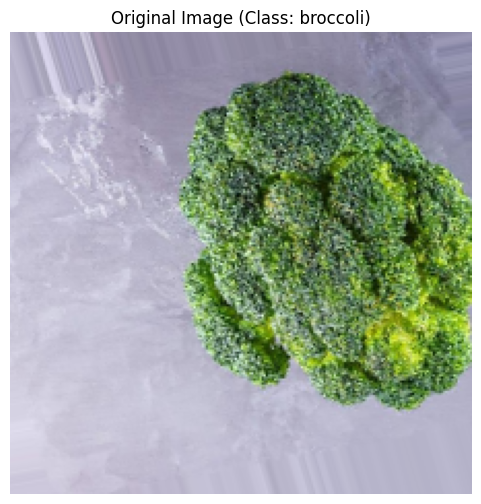

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the directory paths for training and validation data
train_dir = os.path.join(local_base_dir, 'train')
val_dir = os.path.join(local_base_dir, 'val')

# Create the training and validation data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Select the first image from the batch for visualization
original_image = images[0]
original_label = labels[0]

# Find the class name for the original image
class_names = list(train_generator.class_indices.keys())
original_class_name = class_names[np.argmax(original_label)]

plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title(f"Original Image (Class: {original_class_name})")
plt.axis('off')
plt.show()

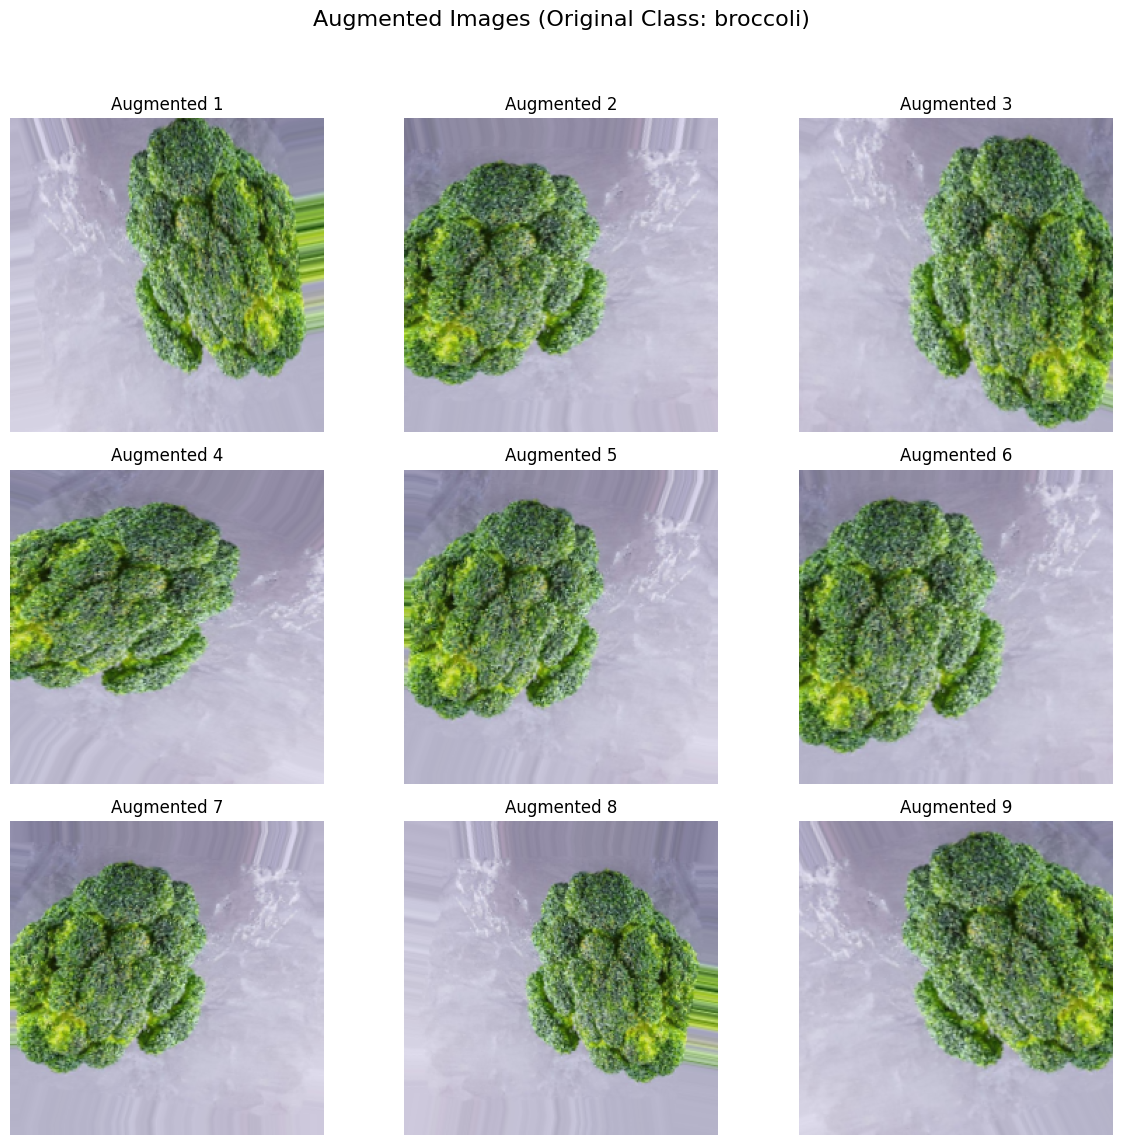

In [ ]:
# Show multiple augmented versions of the selected image
plt.figure(figsize=(12, 12))
for i in range(9):
    # Apply augmentation to the single image (ImageDataGenerator expects a batch, so expand dims)
    augmented_image = train_datagen.random_transform(original_image)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image)
    plt.title(f"Augmented {i+1}")
    plt.axis('off')
plt.suptitle(f"Augmented Images (Original Class: {original_class_name})", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    'dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 6998 images belonging to 10 classes.
Found 1475 images belonging to 10 classes.
Found 1499 images belonging to 10 classes.


In [ ]:
base_model = ResNet50(
    weights=None,
    include_top=False,
    pooling='avg',
    input_shape=(224,224,3)
)

In [ ]:
model = Sequential([
    base_model,

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 24,588,810 (93.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5297s 24s/step - accuracy: 0.4100 - loss: 1.8207 - val_accuracy: 0.1376 - val_loss: 3.7026 - learning_rate: 0.0010
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 166s 757ms/step - accuracy: 0.6398 - loss: 1.0930 - val_accuracy: 0.3064 - val_loss: 3.0227 - learning_rate: 0.0010
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 167s 763ms/step - accuracy: 0.7318 - loss: 0.8491 - val_accuracy: 0.3973 - val_loss: 2.1224 - learning_rate: 0.0010
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 168s 766ms/step - accuracy: 0.7725 - loss: 0.7003 - val_accuracy: 0.6766 - val_loss: 1.4298 - learning_rate: 0.0010
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 202s 764ms/step - accuracy: 0.8182 - loss: 0.5817 - val_accuracy: 0.7363 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 167s 760ms/step - accuracy: 0.8307 - loss: 0.5334 - val_accuracy: 0.5810 - val_loss: 2.0398 - learning_rate: 0.0010
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 162s 741ms/step - 

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1171s 25s/step - accuracy: 0.9406 - loss: 0.1703
Test Accuracy: 0.9406270980834961


In [ ]:
predictions = model.predict(test_generator)

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 324ms/step


In [ ]:
import os

# Define the directory path where the model will be saved
save_dir = '/content/drive/MyDrive/DeepLearning'

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save the model
model.save(os.path.join(save_dir, 'resnet50_model.keras'))
print(f"Model saved successfully to {os.path.join(save_dir, 'resnet50_model.keras')}")

Model saved successfully to /content/drive/MyDrive/DeepLearning/resnet50_model.keras


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/DeepLearning/resnet50_model.keras')

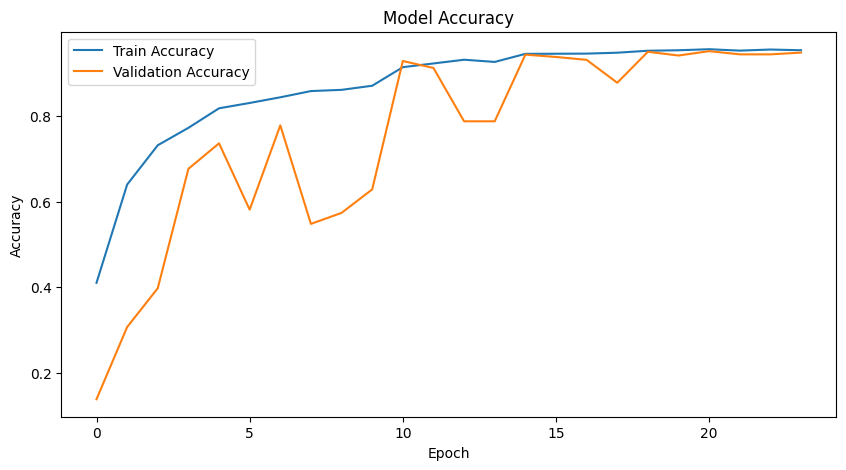

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

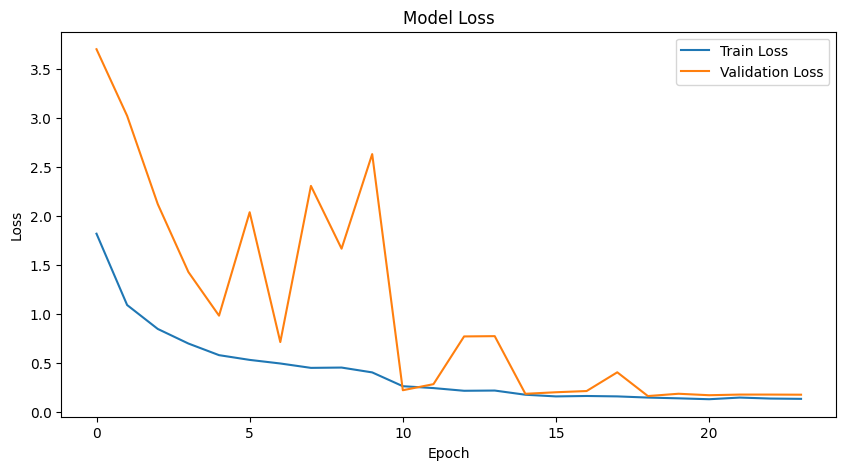

In [ ]:
# Loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 333ms/step


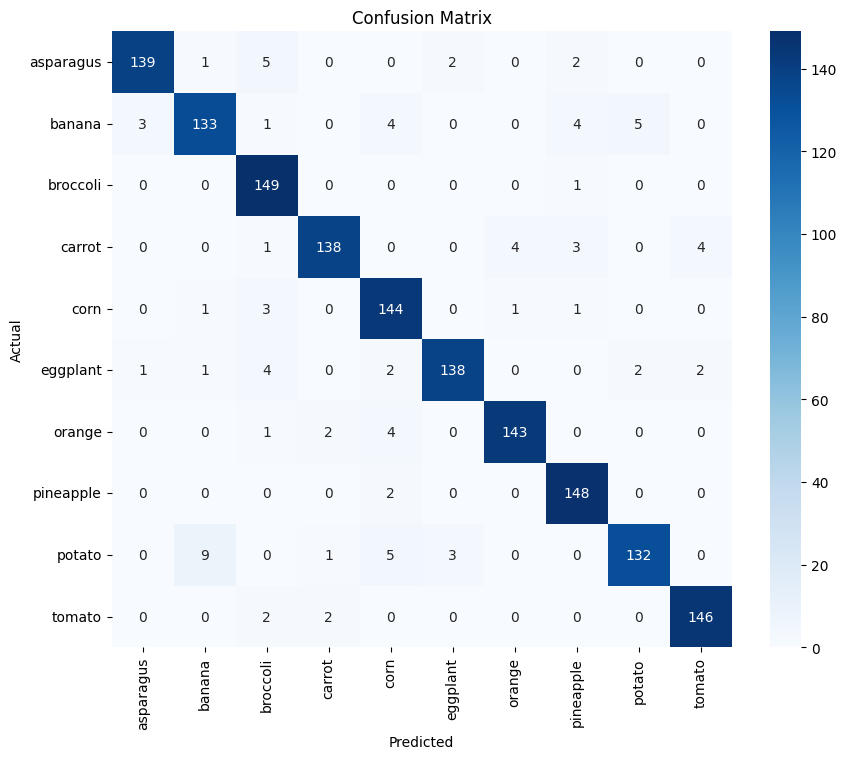

In [ ]:
pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

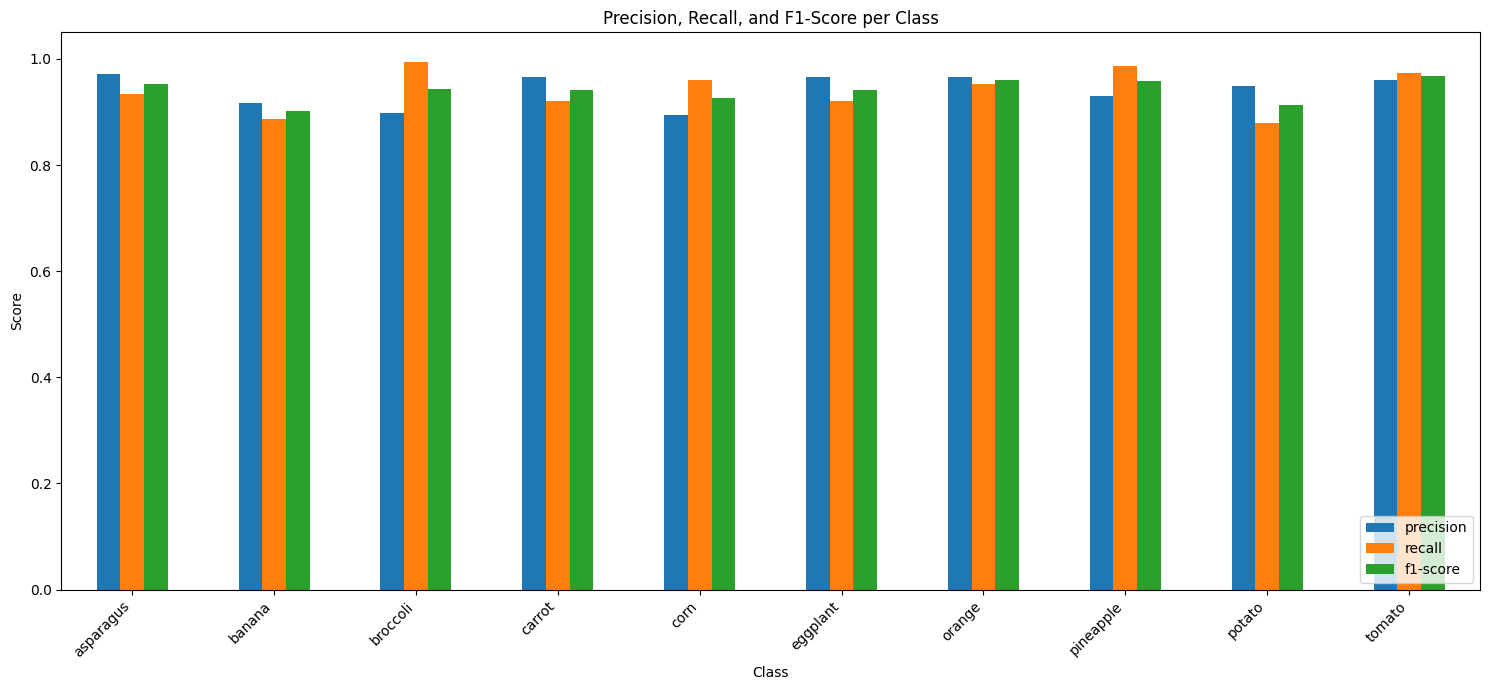

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the classification report as a dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Convert to a pandas DataFrame and remove 'accuracy', 'macro avg', 'weighted avg'
df_report = pd.DataFrame(report).transpose()
df_report = df_report.drop(columns=['support'])
df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'])

# Plotting the metrics
df_report.plot(kind='bar', figsize=(15, 7))
plt.title('Precision, Recall, and F1-Score per Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

   asparagus       0.97      0.93      0.95       149
      banana       0.92      0.89      0.90       150
    broccoli       0.90      0.99      0.94       150
      carrot       0.97      0.92      0.94       150
        corn       0.89      0.96      0.93       150
    eggplant       0.97      0.92      0.94       150
      orange       0.97      0.95      0.96       150
   pineapple       0.93      0.99      0.96       150
      potato       0.95      0.88      0.91       150
      tomato       0.96      0.97      0.97       150

    accuracy                           0.94      1499
   macro avg       0.94      0.94      0.94      1499
weighted avg       0.94      0.94      0.94      1499



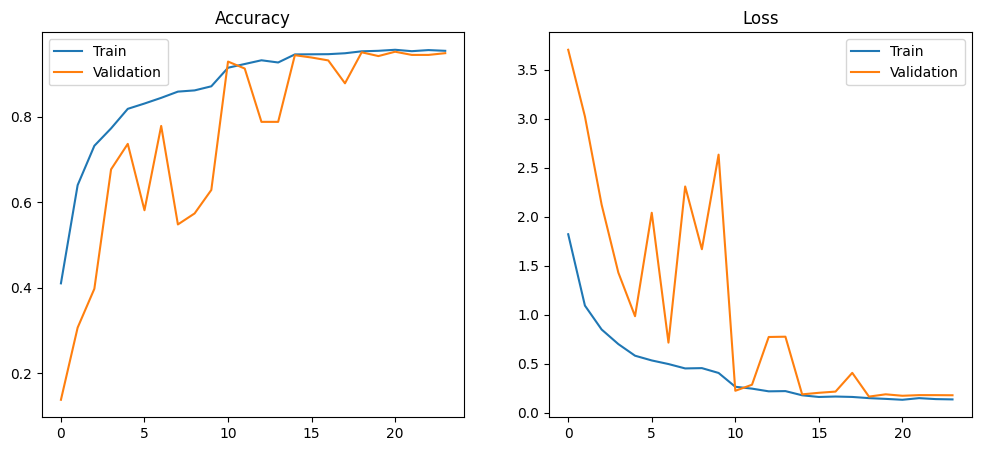

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()